# Модель предсказания отмены бронирования номеров в отеле

## Общая информация

- Компания UrbanStay - представитель гостиничного бизнеса.
- Цель компании —  максимизация прибыли сети отелей.
- Ключевой фактор, который снижает прибыль компании и мешает ее нормальному функционированию - отмена броней номеров незадолго до заселения. 

## Проблема

Клиенты отменяют брони номеров в последний момент.

Последствия для бизнеса:
- упущенная выручка
- нарушение нормального функционирование бизнеса (персонал то перегружен, то проставивает; продукты портятся и тд.)
- потеря доверия со стороны партнеров (штрафы и отказы в сотрудничестве)

## Текущее решение 

Овербукинг
- такой подход основан на интуиции, что ненадежно и неконтроллируемо. Есть репутационные риски при просчете

## Бизнес-требования

Необходимо разработать инструмент, который позволит:

1. Заранее выявлять рискованные бронирования, то есть те, что с высокой вероятностью будут отменены.
2. Принимать превентивные меры — например, предлагать неуверенным клиентам гибкие условия или альтернативные даты, чтобы сохранить бронь.
3. Снизить долю отмен в последний момент с 30% до 10% за ближайшие шесть месяцев

## Ожидаемый эффект 

Если цель будут достигнута, то это улучшит положение UrbanStay:

- Повысит загрузку отелей до 80% и более.
- Сократит потери выручки от простоя номеров.
- Наладит планирование работы персонала и закупок.
- Укрепит доверие партнёров.
- Высвободит ресурсы для развития сервиса.

---
## Цель работы
- создание модели прогнозирования отмены брони на основе данных о клиенте

## Задачи
- разработать модель предсказания вероятности отмены брони
- расчитать экономический эффект от ее внедрения


## ML постановка

**Вид задачи:**
- обучение с учителем
- подтип: классификация

**Целевая переменная:**
- booking_status - статус бронирования: `отказ_брони`, `нет_отказа`

**Данные:**

- hotel_bookings - история бронирования
- hotel_reviews - отзывы проживающих. Текстовые данные, из которых можно выделить дополнительные признаки для модели (feature engineering)

**Метрики**
1. Оценка качества предсказаний моделей: 
    - **accuracy, precision, recall, F1‑мера**
2. Оценка экономического эффекта от внедрения: 

    - Прирост дохода благодаря модели: **IR** (англ. Incremental Revenue)

    - Динамика доли отмен бронирования: $\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \times 100\%$

    - Динамика загрузки отелей: $\text{Динамика загрузки} = \frac{\text{Загрузка отеля до} - \text{Загрузка отеля после}}{\text{Загрузка отеля до}} \times 100\%$


**Используемые технологии**
- Python - загрузка данных, ИАД, формирования итогового датасета, предобработка
- Библиотеки CatBoost, LightGBM, XGBoost для обучения ML моделей градиентного бустинга
- Техника N-gams для векторизации текстовых данных и формирования новых признаков для обучения модели

## Настройка проекта

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from typing import Optional
from sklearn.metrics import classification_report
import optuna
import shap
from sqlalchemy import create_engine

import numpy as np
import re
import os
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk # импортируем библиотеку nltk для обработки текста
nltk.download('stopwords') # скачиваем все существующие стоп-слова

from nltk.corpus import stopwords # импортируем стоп-слова
import string
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# воспроизводимость вычислений
RANDOM_SEED = 42 

In [3]:
# настройка визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

## Этап 1: подготовка данных

### Загрузка данных

In [4]:
load_dotenv(override=True) # автоматически ищет .env в текущей директории

connection_string = 'postgresql://{}:{}@{}:{}/{}?sslmode=require'.format(
    os.getenv('DB_USER', default='praktikum_student'),
    os.getenv('DB_PASSWORD', default='Sdf4$2;d-d30pp'),
    os.getenv('DB_HOST', default='rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'),
    os.getenv('DB_PORT', default='6432'),
    os.getenv('DB_NAME', 'data-scientist-hotels'),
) # параметры должны подгружаться из .env файла. 
# Я не знаю, как загружать доп. файлы на платформу практикума, поэтому поставил креды в дефолт значения

In [5]:
# создание соединения 
engine = create_engine(connection_string)

In [6]:
# sql запросы для извлечения данных

query_hotel_bookings = '''
SELECT *
FROM hotel_bookings
ORDER BY booking_id ASC;
'''

query_hotel_reviews = '''
SELECT *
FROM hotel_reviews
ORDER BY booking_id ASC;
'''

In [7]:
df_hotel_bookings = pd.read_sql_query(query_hotel_bookings, con=engine)

In [8]:
df_hotel_reviews = pd.read_sql_query(query_hotel_reviews, con=engine)

In [9]:
display(df_hotel_bookings.info(), df_hotel_bookings.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

None

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [10]:
display(df_hotel_reviews.info(), df_hotel_reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB


None

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


Итог:
- корректно загружены данные из двух таблиц: hotel_bookings, hotel_reviews

### Исследовательский анализ данных и предобработка

### Общая информация

In [11]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [12]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [13]:
get_base_df_info(name='hotel_bookings', df=df_hotel_bookings)

Общая информация о датафрейме hotel_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,Метрика,Значение
0,Строк,35341.00
1,Колонок,17.00
2,"Явных дубликатов, %",13.04
3,Категориальных колонок,6.00
4,Числовых колонок,9.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,30733
booking_date,object,0,0.0,2445
booking_value,float64,0,0.0,1766
days_until_checkin,int64,0,0.0,79
weekday_nights,int64,0,0.0,14
room_type,object,0,0.0,7
adult_count,int64,0,0.0,6
previous_cancellations,int64,0,0.0,6
previous_no_shows,int64,0,0.0,6
customer_special_requests,int64,0,0.0,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,booking_date,child_count
2,sales_channel,previous_cancellations
3,booking_status,previous_no_shows
4,meal_plan,booking_value
5,room_type,days_until_checkin
6,NaN,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests


--------------------------------------------------


Анализ датасета **hotel_bookings**:
- датасет состоит из: 5 категориальных признаков, 9 числовых, категориальный таргет 
- явных пропусков нет
- 13% явных дубликатов - стоит удалить неинформативные повторы

In [14]:
get_base_df_info(name='hotel_reviews', df=df_hotel_reviews)

Общая информация о датафрейме hotel_reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


,Метрика,Значение
0,Строк,25177.0
1,Колонок,5.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,4.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,21883
review_text,object,0,0.0,14153
customer_id,object,0,0.0,13429
review_date,object,0,0.0,2514
stay_rating,int64,0,0.0,4


Типы колонок


,Категориальные колонки,Числовые колонки
0,customer_id,stay_rating
1,booking_id,NaN
2,review_date,NaN
3,review_text,NaN


--------------------------------------------------


Анализ датасета **hotel_reviews**:
- датасет состоит из: 4 категориальных признаков, 1 числовой
- явных пропусков и дубликатов нет
- текстовый признак **review_text** стоит векторизовать и сформировать более информативные признаки на его основе

### Анализ распределений 

In [15]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str,
    show_mean: bool = False
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

    if show_mean:
        # горизонтальная линия среднего значения
        plt.axhline(
            y=mean_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Среднее: {mean_value:.1f}",
        )
        plt.legend()

    plt.title(f"Распределение {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)


    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [16]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30,
    hue: Optional[str]=None
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins, hue=hue, legend=True)
    
    plt.figtext(
        0.75,0.4, 
        df[feature_name].describe().to_string(), 
        fontsize=10,
        family="monospace",  # Ensures perfect columns alignment
        verticalalignment="center",
        bbox=dict(boxstyle="square,pad=0.6", facecolor="#f8f9fa", edgecolor="gray"),
    )

    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

### Таблица **hotel_bookings**

In [17]:
cat_cols, num_cols = get_cat_num_cols(df=df_hotel_bookings)
target_col = 'booking_status'
cat_cols_feat = [col for col in cat_cols if col != target_col]
num_cols_feat = num_cols.copy()

#### Таргет

In [18]:
df_hotel_bookings[target_col].describe()

count          35341
unique             2
top       нет_отказа
freq           25177
Name: booking_status, dtype: object

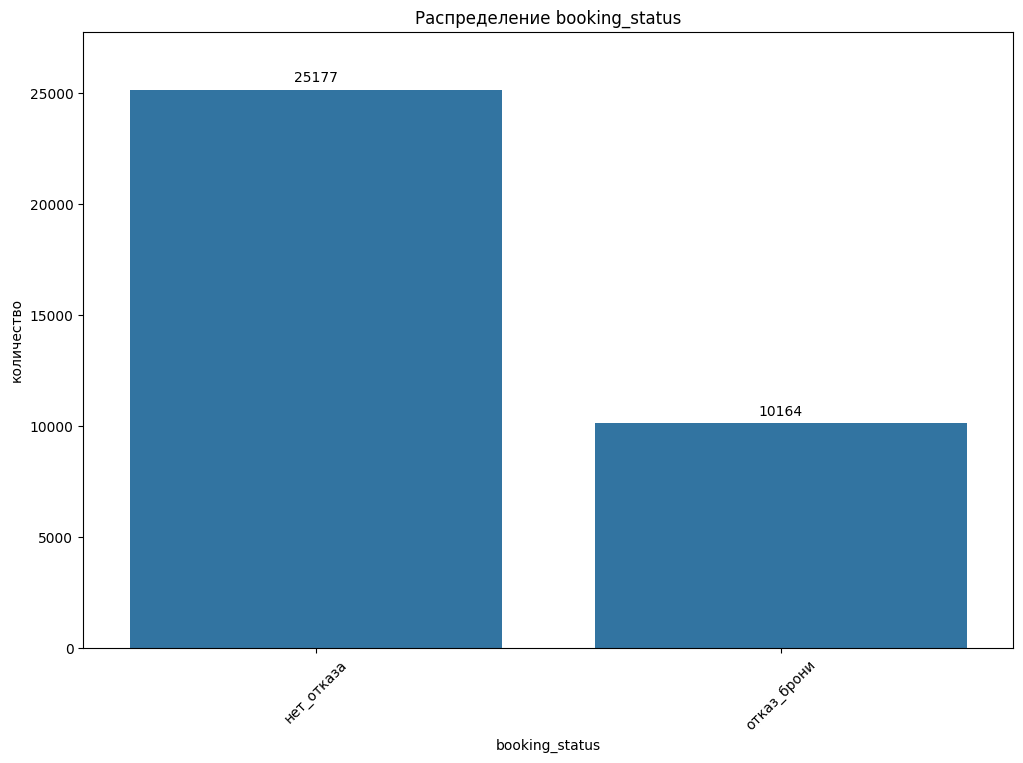

In [19]:
plot_count_bars(df_hotel_bookings, target_col)

In [20]:
df_hotel_bookings[target_col].value_counts() / len(df_hotel_bookings[target_col]) * 100

booking_status
нет_отказа     71.240203
отказ_брони    28.759797
Name: count, dtype: float64

Анализ:
- классы внутри таргета распределеные неравномерно 
- Дисбаланс 71/29% не является критическим, поэтому методы балансировки применять нет необходимости 

#### Категориальные признаки

In [21]:
# исключение технических признаков id 
no_analyse_col_feats = ['booking_id', 'booking_date']
cat_cols_feat = [col for col in cat_cols_feat if col not in no_analyse_col_feats]
cat_cols_feat

['sales_channel', 'meal_plan', 'room_type']

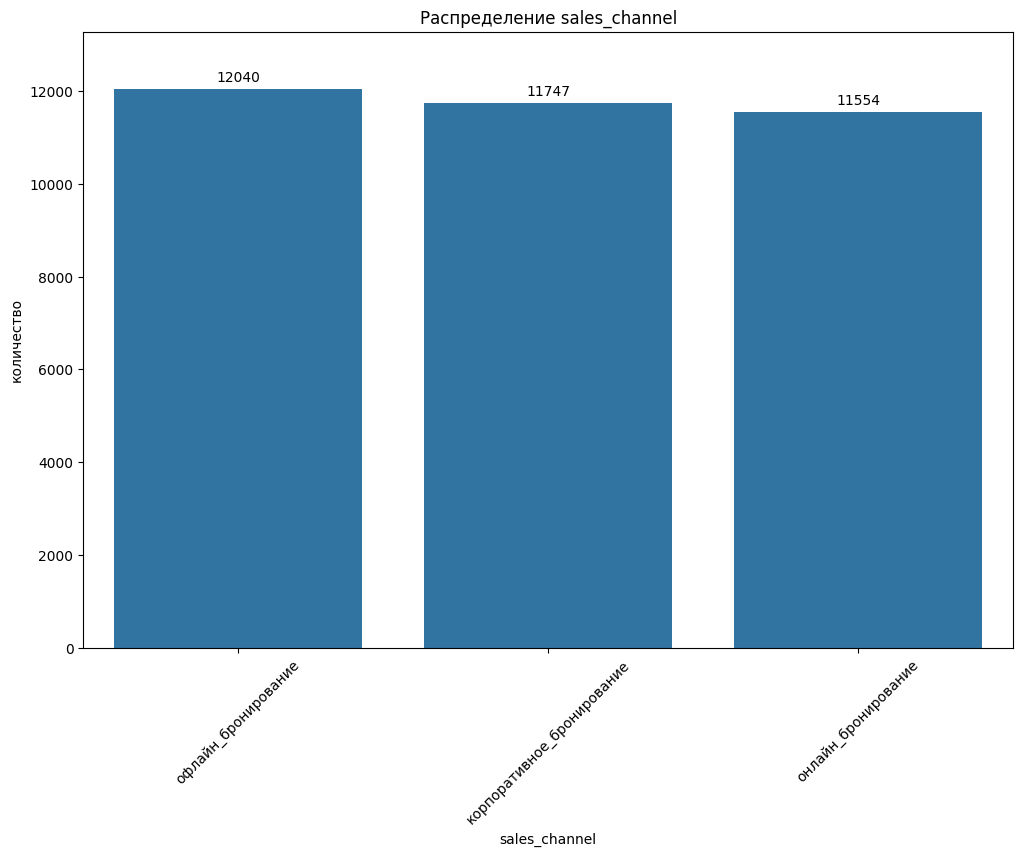

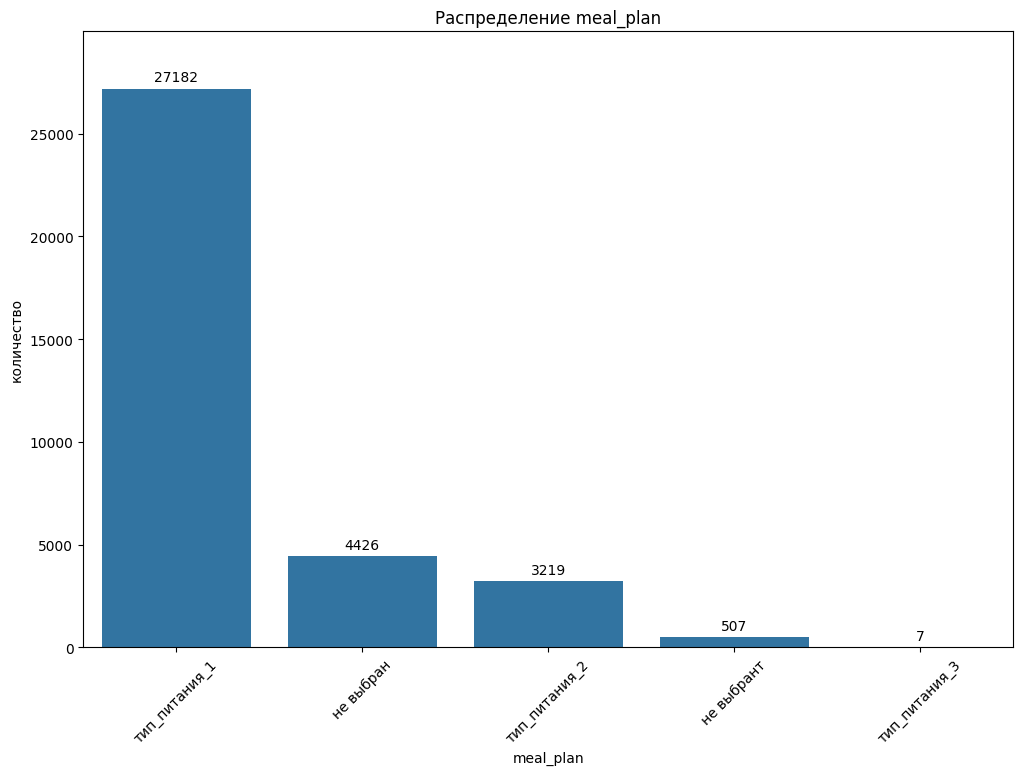

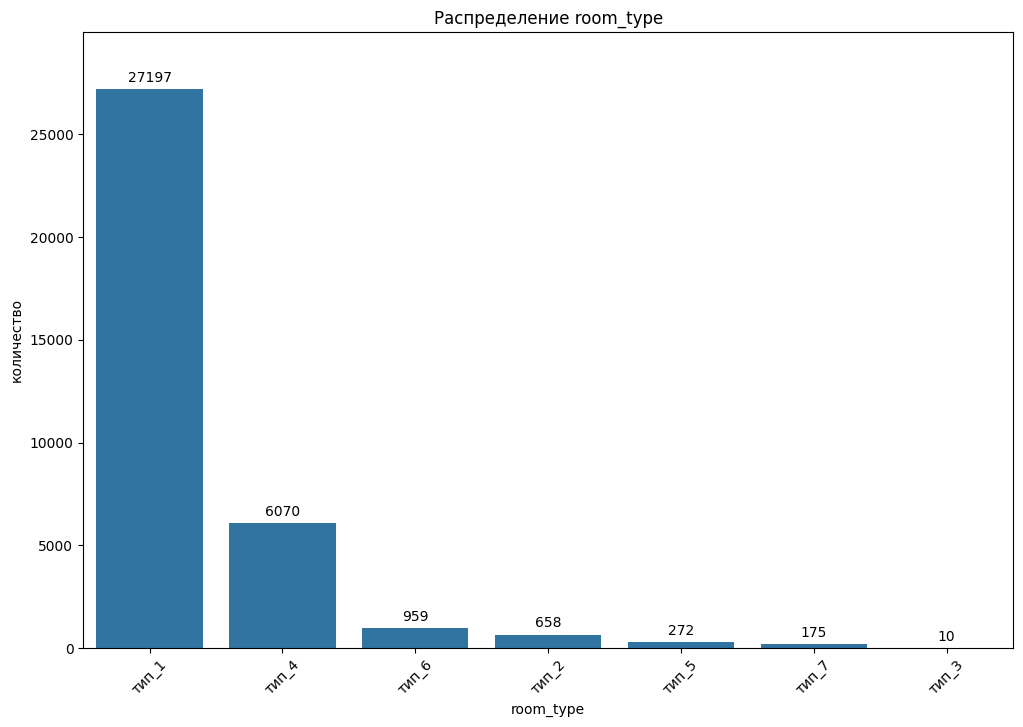

In [22]:
for name in cat_cols_feat:
    plot_count_bars(df=df_hotel_bookings, col_name=name)

Анализ:
- sales_channel: по способу оформления брони распределение равномерное
- meal_plan: 
    - По типу питания существенно лидирует 1 тип. 
    - Присутствует категория с опечаткой в названии. Стоит объединить `не выбран` и `не выбрант` в один признак. Он будет второй по популярности
    - 2ой тип в 9 раз уступает по популярности 1ому
    - 3 тип крайне малочисленный - всего 7шт, в то время как 1ого типа около 27к

- room_type: 
    - существенно преобладает тип_1 - 27к
    - на втором месте тип_4 с 6к
    - остальные менее 1к

#### Количественные признаки 

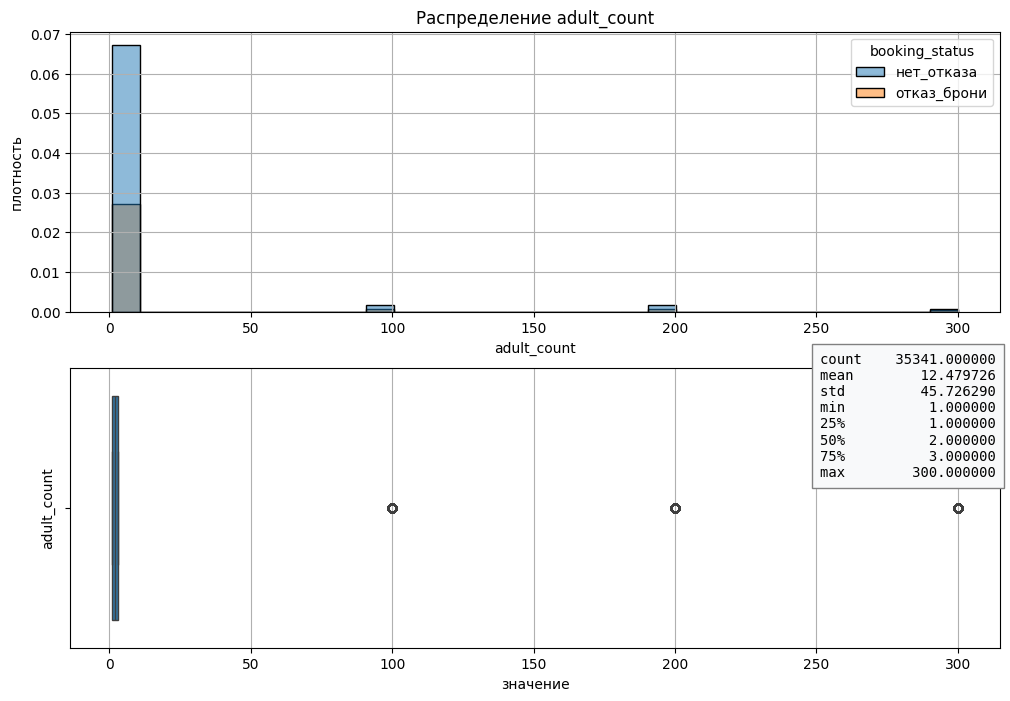

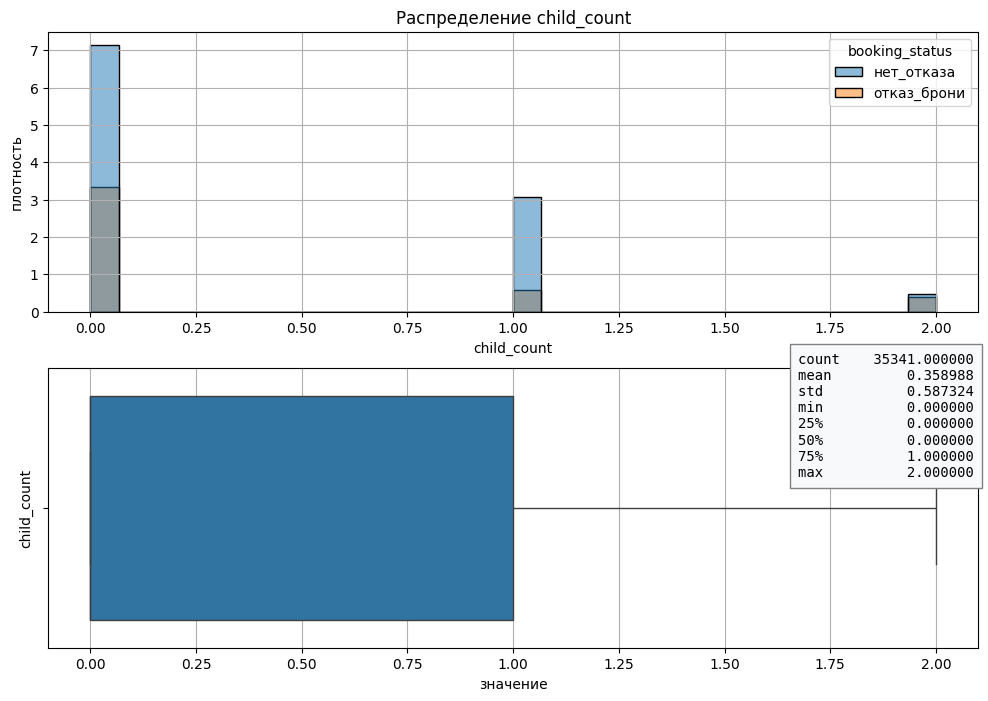

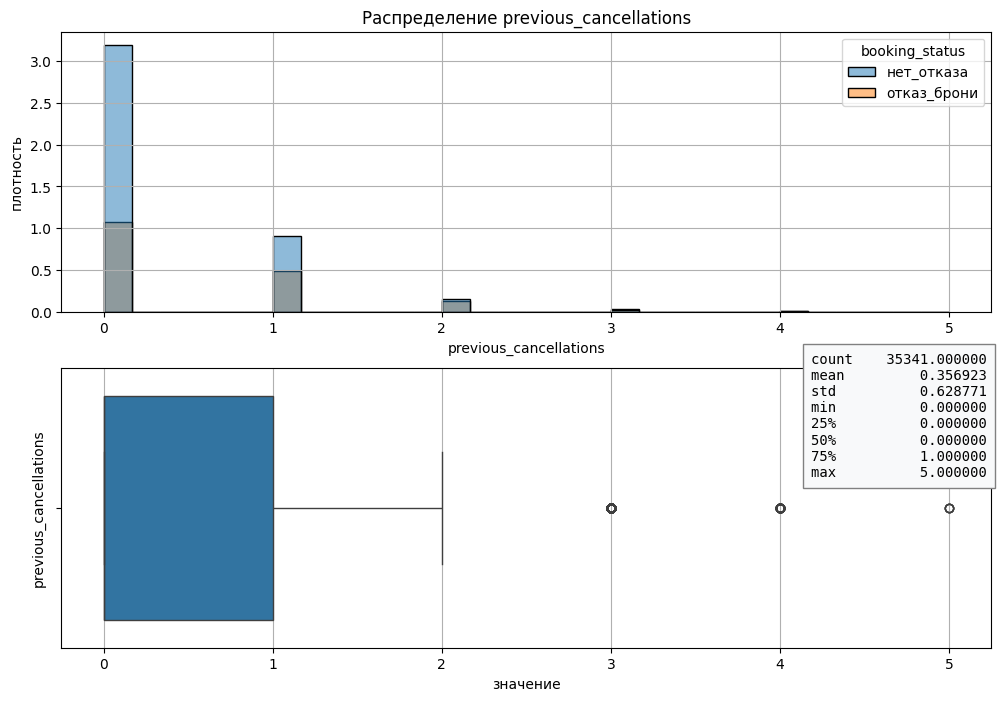

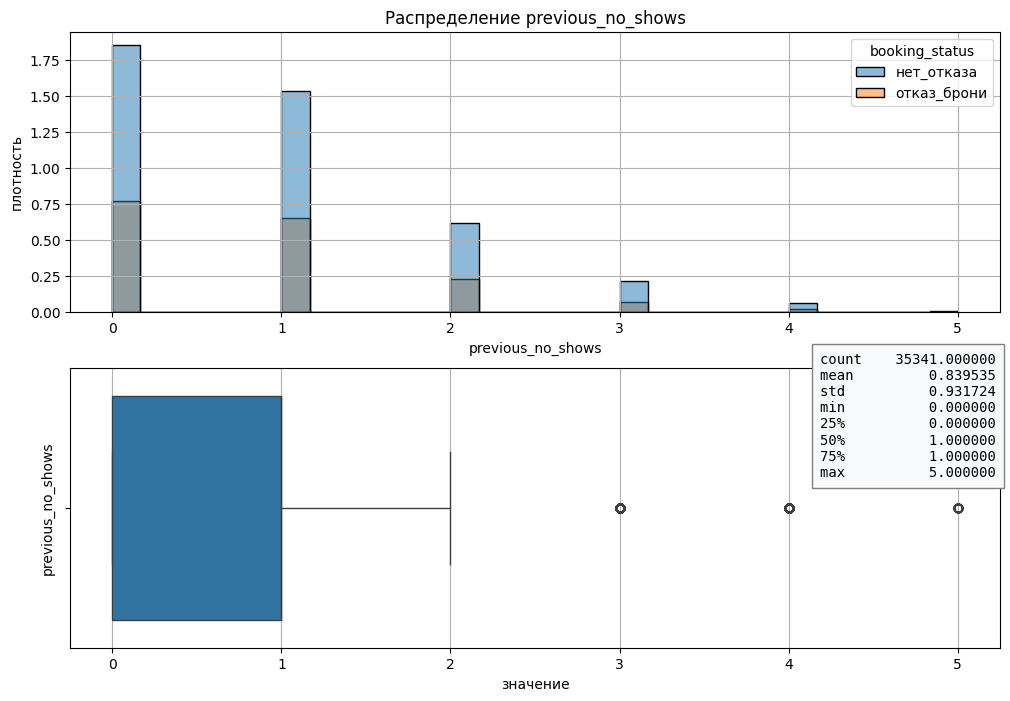

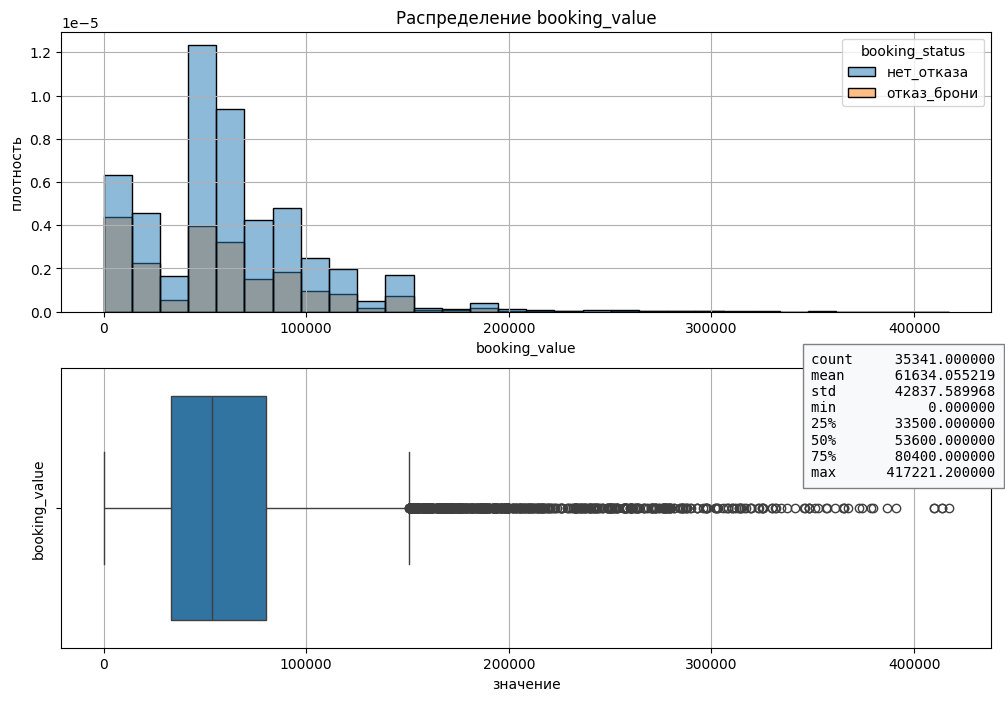

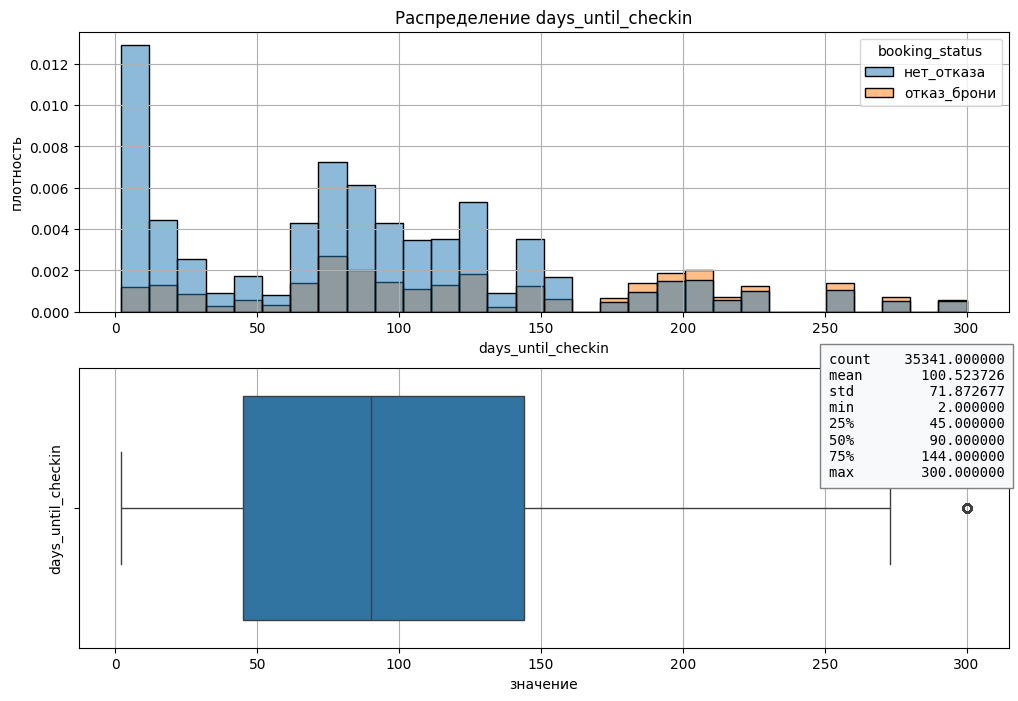

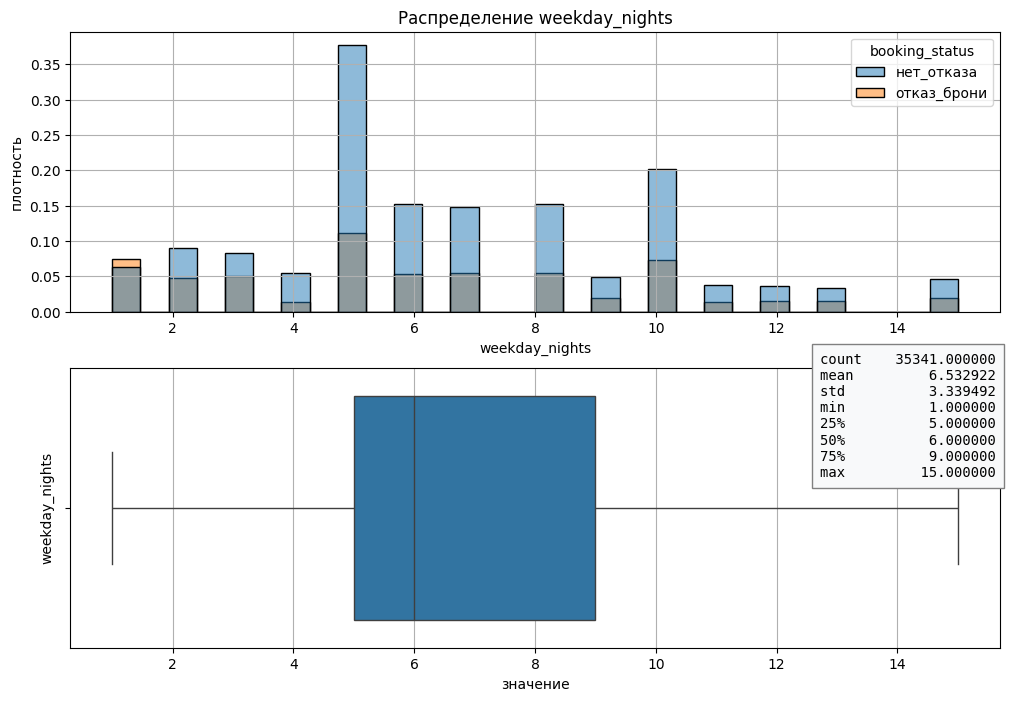

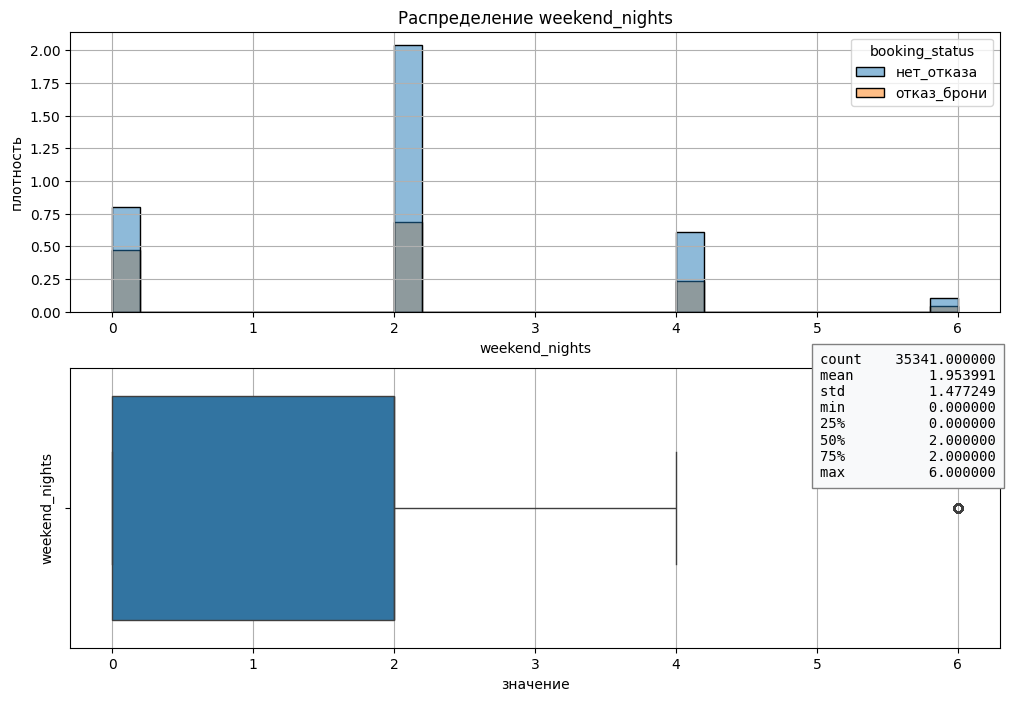

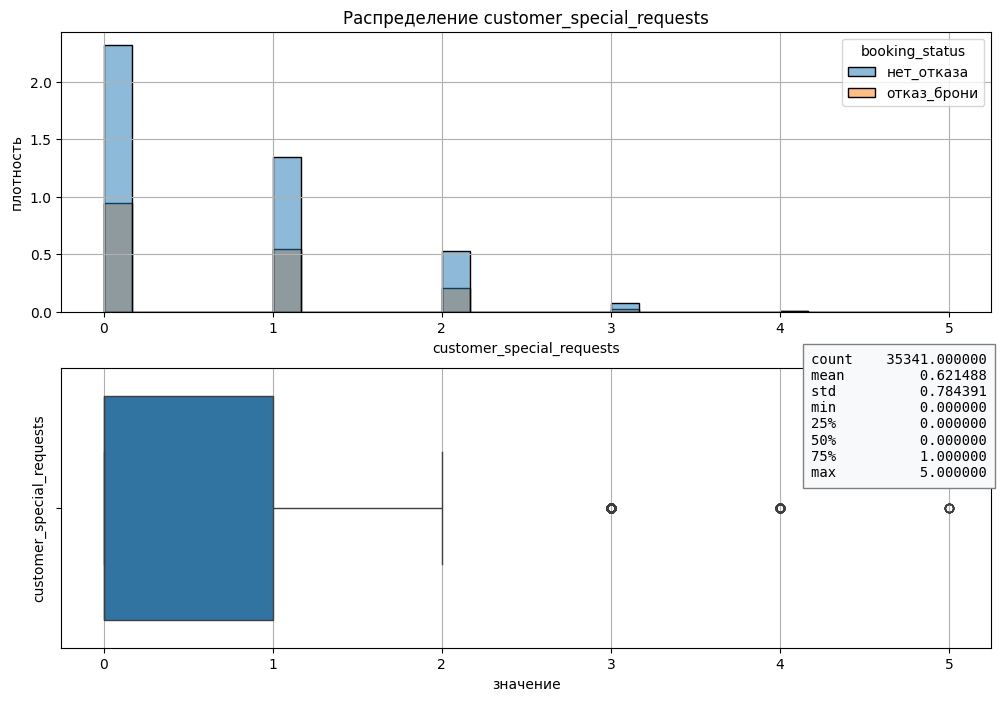

In [23]:
for name in num_cols_feat:
    plot_hist_box(df=df_hotel_bookings, feature_name=name, hue=target_col)

Анализ:
- adult_count: в основном 1-3 взрослых в номерах. Значения 100+ скорее всего относятся к корпоративным броням
- child_count: более 50% заселений без детей, с 1-2 детьми заселяются гораздо реже. С 2мя детьми доля отказов существенно выше, чем в других случаях
- previous_cancellations: экспоненциально убывает количество предыдущих отмен броней. При этом доля отмен растет - чем больше в прошлом было отмен, тем вероятней сейчас тоже отменит
- previous_no_shows: экспоненциально убывает количество неподтвержденных броней. 
- booking_value: итоговая стоимость бронирования сосредоточена в интервале 0-200к. Присутствуют малочисленные выбросы +400к
- days_until_checkin: в основном бронируют номера незадолго до заселения (пик по частоте 2-10 дней). При этом доля отмен выше среди длительных сроков броней.
- weekend_nights: наиболее часто 5 дней. Наиболее высокая доля отказов при 1 ночи
- weekday_nights: в основном 2 дня. Явных зависимостей с таргетом не видно
- customer_special_requests: кол-во просьб убывает экспоненциально.  Явных зависимостей с таргетом не прослеживается

### Таблица **hotel_reviews**

In [24]:
df_hotel_reviews.columns

Index(['customer_id', 'booking_id', 'review_date', 'stay_rating',
       'review_text'],
      dtype='object')

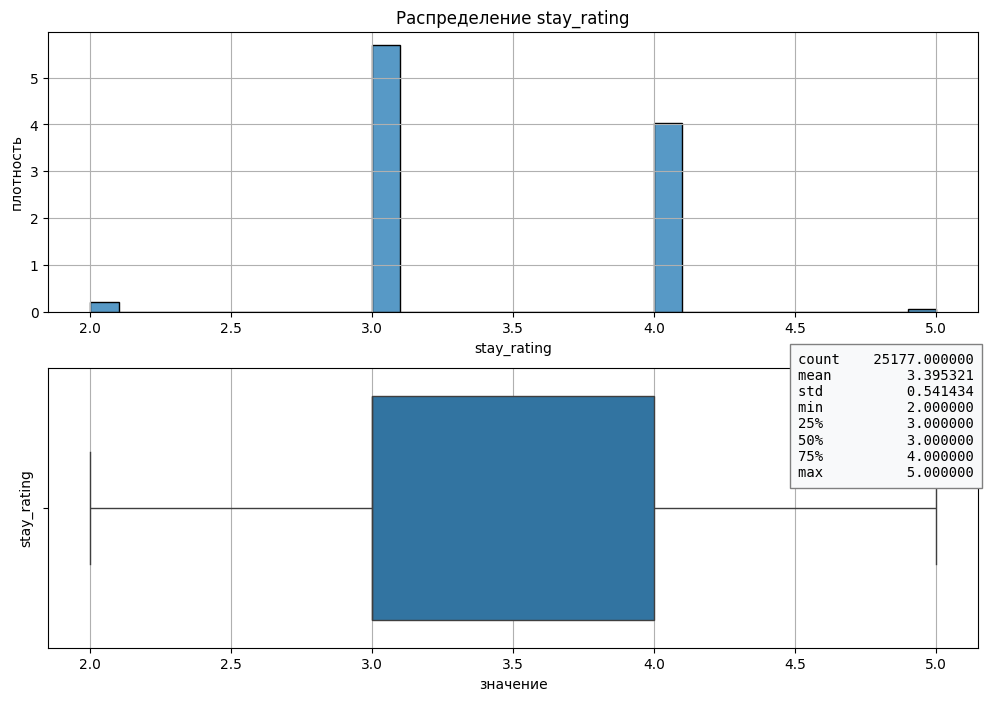

In [25]:
plot_hist_box(df=df_hotel_reviews, feature_name='stay_rating')

In [26]:
# доля уникальных отзывов
df_hotel_reviews['review_text'].nunique() / len(df_hotel_reviews) * 100

56.2140048456925

In [27]:
df_hotel_reviews['review_text'].value_counts()

review_text
Отличный отель! хорошие виды из окон.                                                                                                                                  42
Отличный отель! достаточное освещение.                                                                                                                                 40
Отличный отель! приятная музыка в лобби.                                                                                                                               38
Отличный отель! качественные продукты на завтрак.                                                                                                                      37
Отличный отель! вежливый персонал.                                                                                                                                     37
                                                                                                                                          

Анализ:
- stay_rating: основные оценки 3,4. 2,5 - редко ставят. 
- review_text: уникальных отзывов около 56%. Большое количество отднотипных отзывов существенно упростит векторизацию и формирование новых признаков.

### Объединение таблиц

In [28]:
# чистка от явных дублей
init_len_df_hotel_bookings = len(df_hotel_bookings)

df_hotel_bookings.drop_duplicates(inplace=True)

print('Потери при устранении дублей (%): ', (init_len_df_hotel_bookings - len(df_hotel_bookings)) / init_len_df_hotel_bookings * 100 )

Потери при устранении дублей (%):  13.03868028635296


In [29]:
# Преобразование типов
df_hotel_bookings['booking_date'] = pd.to_datetime(df_hotel_bookings['booking_date'])
df_hotel_reviews['review_date'] = pd.to_datetime(df_hotel_reviews['review_date'])

In [30]:
# будущий id брони для клиента
df_hotel_reviews['future_booking_id'] = df_hotel_reviews.sort_values(by=['customer_id', 'review_date']).groupby('customer_id')['booking_id'].shift(-1)
df_hotel_reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text,future_booking_id
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в...",INN00001
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не...",INN00002
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...,NaN
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни...",NaN
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...,INN00005


In [31]:
df_total = pd.merge(
    df_hotel_bookings, 
    df_hotel_reviews.drop(columns='booking_id'), 
    how='left',
    left_on='booking_id',
    right_on='future_booking_id',
).drop(columns='future_booking_id')
get_base_df_info('df_total', df_total)

Общая информация о датафрейме df_total


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,...,1,0,тип_питания_2,False,тип_1,0,NaN,NaT,NaN,NaN
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,...,5,2,тип_питания_2,False,тип_1,1,C0001,2020-08-21,3.0,"Неплохо. тихо и спокойно, но отсутствие фена в..."
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,...,5,2,тип_питания_1,False,тип_1,0,C0001,2021-10-15,3.0,"Неплохо. красивое оформление территории, но не..."
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,...,6,2,тип_питания_1,False,тип_1,0,NaN,NaT,NaN,NaN
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,...,5,2,тип_питания_1,False,тип_1,1,NaN,NaT,NaN,NaN


,Метрика,Значение
0,Строк,32169.0
1,Колонок,21.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,7.0
4,Числовых колонок,10.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
review_text,object,20421,63.48,8149
customer_id,object,20421,63.48,6553
review_date,datetime64[ns],20421,63.48,2183
stay_rating,float64,20421,63.48,5
booking_id,object,0,0.00,30733
booking_date,datetime64[ns],0,0.00,2445
booking_value,float64,0,0.00,1766
days_until_checkin,int64,0,0.00,79
weekday_nights,int64,0,0.00,14
room_type,object,0,0.00,7


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,sales_channel,child_count
2,booking_status,previous_cancellations
3,meal_plan,previous_no_shows
4,room_type,booking_value
5,customer_id,days_until_checkin
6,review_text,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests
9,NaN,stay_rating


--------------------------------------------------


Итог:
- проведено преобразование типов данных к datetime в таблицах перед соединением, проведена сортировка по датам
- потери при устранении дублей в таблице hotel_bookings: 13%
- создана общая таблица с информацией о бронировании и отзывах клиентов
- информация по отзывам присоединена по правилу: ближайший отзыв клиента с прошлой брони номера
- в итоговой таблице 63.48% записей о бронировании без отзывов и рейтингов. Это существенное количество. Пропуски оставляются как есть. При предобработке можно поменять на значение-флаг, чтобы модель эти данные также учла.


### Создание новых признаков

In [32]:
# сезонность в виде месяца планируемого заезда
df_total = df_total.sort_values(by='booking_id')
df_total['checkin_month'] = (df_total['booking_date'] + pd.to_timedelta(df_total['days_until_checkin'], unit='days')).dt.month

In [33]:
# лояльность клиента: кол-во предыдущих броней
df_total['prev_booking_count'] = df_total.groupby('customer_id')['booking_id'].cumcount()

#### Формирование признака на основе текста отзыва

In [34]:
# Загрузка стоп-слов и пунктуации
nltk.download('stopwords')
nltk.download('punkt')
nltk.download("punkt_tab")
stop_words = set(stopwords.words('russian'))
punctuation = set(string.punctuation)

morph = pymorphy3.MorphAnalyzer()

def preprocess_text(text):

    words = word_tokenize(text.lower())
    lemmatized_words = [morph.parse(word)[0].normal_form for word in words]
    filtered_words = [
        word
        for word in lemmatized_words
        if word not in stop_words and word not in punctuation
    ]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [35]:
tfidf_vectorizer = TfidfVectorizer()

df_total["clean_review"] = df_total[
    "review_text"
].fillna('').apply(preprocess_text)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_total["clean_review"]
)
feature_names = tfidf_vectorizer.get_feature_names_out()

In [36]:
# суммарный TF-IDF каждого слова по всем отзывам
tfidf_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

top_n = 30
top_indices = tfidf_scores.argsort()[::-1][:top_n]

top_tfidf_words = pd.DataFrame({
    "word": feature_names[top_indices],
    "tfidf_score": tfidf_scores[top_indices]
})

top_words = set(top_tfidf_words["word"])


In [37]:
# Список для хранения одного главного слова отзыва
top_single_words = []

# Проходим по строкам матрицы TF-IDF
for i in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix[i].toarray().ravel()

    # Проверяем, есть ли вообще слова в этом отзыве (максимальный вес > 0)
    if row.max() > 0:
        # Находим индекс слова с самым большим весом TF-IDF
        top_word_idx = row.argmax()
        # Извлекаем само слово
        top_word = feature_names[top_word_idx]
    else:
        # Если отзыв пустой или состоял только из стоп-слов
        top_word = "другое"

    top_single_words.append(top_word)

# Добавляем результат в DataFrame и сразу переводим в категориальный тип
df_total["main_review_word"] = pd.Series(
    top_single_words, dtype="category"
)

In [38]:
df_total["main_review_word"] = df_total["main_review_word"].where(
    df_total["main_review_word"].isin(top_words),
    "другое"
).astype("category")

In [39]:
df_total[["review_text", "main_review_word"]].head()

,review_text,main_review_word
0,NaN,другое
1,"Неплохо. тихо и спокойно, но отсутствие фена в...",другое
2,"Неплохо. красивое оформление территории, но не...",другое
3,NaN,другое
4,NaN,другое


In [40]:
df_total['main_review_word'].unique()

['другое', 'отель', 'номер', 'кондиционер', 'ребёнок', ..., 'удобный', 'завтрак', 'холодно', 'хороший', 'ванная']
Length: 13
Categories (231, object): ['администрация', 'аккуратный', 'аромат', 'атмосфера', ..., 'чисто', 'чувствовать', 'шумоизоляция', 'это']

Итог:
- сформировано 3 признака на основе информации об отзывах и предыдущих бронях клиентов: 
    - checkin_month - отражает сезонность, 
    - prev_booking_count - отражает лояльность, 
    - main_review_word - категориальный признак с наиболее важными словами из всех отзывов по метрике TF-IDF

### Предобработка по результатам ИАД

In [41]:
# чистка от неинформативных признаков
df_total = df_total.drop(columns=["review_text", 'booking_id', 'booking_date', 'customer_id', 'review_date', 'clean_review'])

In [42]:
# правка опечаток
df_total['meal_plan'] = df_total['meal_plan'].replace('не выбрант', "не выбран")
df_total['meal_plan'].unique()

array(['тип_питания_2', 'тип_питания_1', 'не выбран', 'тип_питания_3'],
      dtype=object)

In [43]:
dupl_part = df_total.duplicated().sum() / len(df_total) * 100

df_total = df_total.drop_duplicates()
print('Потери при очистке дублей (%): ', dupl_part)

Потери при очистке дублей (%):  0.08704031831887842


In [44]:
cat_cols, num_cols = get_cat_num_cols(df_total)

In [45]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32141 entries, 0 to 32168
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   sales_channel              32141 non-null  object  
 1   adult_count                32141 non-null  int64   
 2   child_count                32141 non-null  int64   
 3   returning_customer         32141 non-null  bool    
 4   previous_cancellations     32141 non-null  int64   
 5   previous_no_shows          32141 non-null  int64   
 6   booking_status             32141 non-null  object  
 7   booking_value              32141 non-null  float64 
 8   days_until_checkin         32141 non-null  int64   
 9   weekday_nights             32141 non-null  int64   
 10  weekend_nights             32141 non-null  int64   
 11  meal_plan                  32141 non-null  object  
 12  parking_included           32141 non-null  bool    
 13  room_type                  32141 non

In [46]:
for col in cat_cols:
	# приведение всех категориальных признаков к pd.categorical
	df_total[col] = df_total[col].astype('category')

In [47]:
# приведение таргета к бинарному виду
df_total["booking_status"] = (
    df_total["booking_status"]
    .map({"отказ_брони": 1, "нет_отказа": 0})
    .astype("int8")
)
df_total["booking_status"].unique()

array([0, 1], dtype=int8)

In [48]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32141 entries, 0 to 32168
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   sales_channel              32141 non-null  category
 1   adult_count                32141 non-null  int64   
 2   child_count                32141 non-null  int64   
 3   returning_customer         32141 non-null  bool    
 4   previous_cancellations     32141 non-null  int64   
 5   previous_no_shows          32141 non-null  int64   
 6   booking_status             32141 non-null  int8    
 7   booking_value              32141 non-null  float64 
 8   days_until_checkin         32141 non-null  int64   
 9   weekday_nights             32141 non-null  int64   
 10  weekend_nights             32141 non-null  int64   
 11  meal_plan                  32141 non-null  category
 12  parking_included           32141 non-null  bool    
 13  room_type                  32141 non

### Анализ итоговой таблицы

In [49]:
get_base_df_info('df_total', df_total)

Общая информация о датафрейме df_total


,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,checkin_month,prev_booking_count,main_review_word
0,корпоративное_бронирование,300,0,False,0,0,0,6700.0,21,1,0,тип_питания_2,False,тип_1,0,NaN,7,NaN,другое
1,корпоративное_бронирование,3,0,True,0,1,0,62300.0,15,5,2,тип_питания_2,False,тип_1,1,3.0,10,0.0,другое
2,корпоративное_бронирование,3,0,True,0,2,0,46900.0,96,5,2,тип_питания_1,False,тип_1,0,3.0,2,1.0,другое
3,онлайн_бронирование,2,0,False,0,0,0,53600.0,150,6,2,тип_питания_1,False,тип_1,0,NaN,7,NaN,другое
4,корпоративное_бронирование,1,0,True,1,1,0,46900.0,96,5,2,тип_питания_1,False,тип_1,1,NaN,6,NaN,другое


,Метрика,Значение
0,Строк,32141.0
1,Колонок,19.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,4.0
4,Числовых колонок,13.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
prev_booking_count,float64,20395,63.45,8
stay_rating,float64,20395,63.45,5
booking_value,float64,0,0.00,1766
days_until_checkin,int64,0,0.00,79
weekday_nights,int64,0,0.00,14
main_review_word,category,0,0.00,13
checkin_month,int32,0,0.00,12
room_type,category,0,0.00,7
adult_count,int64,0,0.00,6
previous_cancellations,int64,0,0.00,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,sales_channel,adult_count
1,meal_plan,child_count
2,room_type,previous_cancellations
3,main_review_word,previous_no_shows
4,NaN,booking_status
5,NaN,booking_value
6,NaN,days_until_checkin
7,NaN,weekday_nights
8,NaN,weekend_nights
9,NaN,customer_special_requests


--------------------------------------------------


Анализ:
- итоговая таблица состоит из данных о бронировании и информации об отзывах клиентов
- дублей нет. Потери при очистке менее 0.1%
- пропуски есть в признаках prev_booking_count и stay_rating: 63%. Вызвано это тем, что не у всех клиентов есть история броней и не все оставляют отзывы. Процент существенный, оставляем как есть. Модели бустинга умеют работать с пропусками.
- текстовые данные об отзывах клиентов агрегированы и сведены до категориального признака с наиболее важными словами по метрике TF-IDF
- таблица содержит новые признаки checkin_month - отражает сезонность, prev_booking_count - отражает лояльность клиентов.
- таргет "booking_status" преобразован к бинарному флагу: 1 - отмена брони, 0 - бронь подтверждена

## Этап 2: моделирование

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

### Разделение на выборки


In [50]:
X = df_total.drop(columns='booking_status')
y = pd.Series(df_total['booking_status'], name='target')
display(X.shape, y.shape)

(32141, 18)

(32141,)

In [51]:
cat_cols, num_cols = get_cat_num_cols(df=X)
cat_cols

['sales_channel', 'meal_plan', 'room_type', 'main_review_word']

In [52]:
# train 80% и validate 20%
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [53]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [54]:
def inc_rev_metric(y_true, y_pred):
    AvgRev = 64_500
    CostFP = 7000
    LostRev = 64_500
    PerRebooking = 45_000
    cm = confusion_matrix(y_true, y_pred)
    # tp - верно предсказанные отмены бронирования.
    # tn - количество случаев, когда модель не предсказала отмены и бронь 
    # fp — ложные отмены бронирования — модель предсказала отмену, но гости приехали
    # fn — пропущенные отмены — модель не предсказала отмену, но она произошла.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    TotalCancellations = y_true.sum()
    TotalSuccess = len(y_true) - TotalCancellations  # Fixed here

    IR = (
        (TotalSuccess * AvgRev)
        - (TotalCancellations * LostRev)
        - (
            (tp * PerRebooking)
            + (tn * AvgRev)
            - (fp * CostFP)
            - (fn * LostRev)
        )
    )
    return IR

def rel_inc_rev_metric(y_true, y_pred_prev, y_pred_new):
    prev_ir = inc_rev_metric(y_true, y_pred_prev)
    new_ir = inc_rev_metric(y_true, y_pred_new)

    return (new_ir - prev_ir) / prev_ir * 100


def evaluate_model(y_true, y_pred):
    # макро-усреднение лучше работает для несбалансирвоанных данных 
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'inc_metric': inc_rev_metric(y_true, y_pred)
    }
    return metrics

def get_result_df(model_names: list[str], metric_dicts: list[dict]):
    # Преобразование результатов в датафрейм
    df_results = pd.DataFrame({
        name: {
            k: v for k, v in metric_dict.items()
        } for name, metric_dict in zip(model_names, metric_dicts)
    })
    return df_results

### Обучение базовой модели CatBoostClassifier

In [55]:
cbc_model_base = CatBoostClassifier(
    random_state=RANDOM_SEED,
    loss_function="Logloss",
    eval_metric="Logloss",
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=False,
    n_estimators=1500
)

In [56]:
cbc_model_base.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols
)

CatBoostClassifier(early_stopping_rounds=50, eval_metric='Logloss', loss_function='Logloss', n_estimators=1500, random_state=42, use_best_model=True, verbose=False)

In [57]:
y_pred_val_cbc_model_base = cbc_model_base.predict(X_val)

In [58]:
#  отчет по всем метрикам
report = classification_report(y_val, y_pred_val_cbc_model_base)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4642
           1       0.76      0.66      0.71      1786

    accuracy                           0.85      6428
   macro avg       0.82      0.79      0.80      6428
weighted avg       0.84      0.85      0.85      6428



Анализ:
- в целом хороший baseline: f1-score для классов более 0.7
- базовая модель существенно точнее предсказывает более часто встречающийся класс (precision выше на 30%)

Рекомендация:
- необходимо провести оптимизацию параметров, чтобы улучшить качество предсказания

### Обучение базовой модели XGBClassifier

In [59]:
xgb_model_base = XGBClassifier(
    enable_categorical=True,
    n_estimators=1500,
    objective="binary:logistic",
    random_state=RANDOM_SEED,
    eval_metric="logloss", 
    n_jobs=-1, 
    early_stopping_rounds=50       
)


In [60]:
xgb_model_base.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [61]:
y_pred_val_cxgb_model_base = xgb_model_base.predict(X_val)

In [62]:
#  отчет по всем метрикам
report = classification_report(y_val, y_pred_val_cxgb_model_base)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4642
           1       0.75      0.67      0.71      1786

    accuracy                           0.85      6428
   macro avg       0.82      0.79      0.80      6428
weighted avg       0.84      0.85      0.84      6428



Анализ:
- модель уловила основные закономерности и не переобучилась 
- схожая ситуация метрикам предсказания классов: более многочисленный класс предсказыается точнее по всем показателям (precision, recall, f1-score)

Рекомендация:
- оптимизация гиперпараметров

In [63]:
base_model_results = []
base_val_preds = [y_pred_val_cbc_model_base, y_pred_val_cxgb_model_base]

for pred in base_val_preds:
    result = evaluate_model(y_true=y_val, y_pred=pred)
    base_model_results.append(result)

In [64]:
base_model_results_df = get_result_df(
    model_names=['cbc_model_base', 'cxgb_model_base'],
    metric_dicts=base_model_results
)
base_model_results_df

,cbc_model_base,cxgb_model_base
accuracy,8.490977e-01,8.472309e-01
precision_macro,8.195290e-01,8.157874e-01
recall_macro,7.921734e-01,7.922588e-01
f1_macro,8.038998e-01,8.025422e-01
inc_metric,-1.034120e+08,-1.028580e+08


### Оптимизация гиперпараметров

In [81]:
def objective_xgb(trial):
    """
    Функция-цель для оптимизации параметров xgb
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0),
    }

    model = XGBClassifier(
        **params, 
        enable_categorical=True,
        n_estimators=1500,
        objective="binary:logistic",
        random_state=RANDOM_SEED,
        eval_metric="logloss", 
        n_jobs=-1, 
        early_stopping_rounds=50
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    
    y_val_pred = model.predict(X_val)

    score = inc_rev_metric(y_val, y_val_pred)

    return score

In [82]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

In [83]:
# запуск оптимизации
study_xgb = optuna.create_study(direction="maximize", sampler=sampler) 
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True) 

[I 2026-06-28 16:43:12,893] A new study created in memory with name: no-name-99d6dd2c-1ec1-4566-862a-8bd16928bed7


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-28 16:43:13,949] Trial 0 finished with value: -103484000.0 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'gamma': 0.7319939444914656, 'reg_lambda': 5.9865848459837805, 'reg_alpha': 1.5601864128641787}. Best is trial 0 with value: -103484000.0.
[I 2026-06-28 16:43:15,590] Trial 1 finished with value: -102315000.0 and parameters: {'learning_rate': 0.01432169828911152, 'max_depth': 3, 'gamma': 0.8661761471131737, 'reg_lambda': 6.011150121420937, 'reg_alpha': 7.080725780879728}. Best is trial 1 with value: -102315000.0.
[I 2026-06-28 16:43:17,729] Trial 2 finished with value: -102974500.0 and parameters: {'learning_rate': 0.010485387725194618, 'max_depth': 10, 'gamma': 0.8324426424759953, 'reg_lambda': 2.1233911146593702, 'reg_alpha': 1.8182496802527564}. Best is trial 1 with value: -102315000.0.
[I 2026-06-28 16:43:19,214] Trial 3 finished with value: -102572000.0 and parameters: {'learning_rate': 0.015254729458052608, 'max_depth': 5, 'gamma': 0.52475

In [84]:
xgb_best_opt = XGBClassifier(
    **study_xgb.best_params, 
    enable_categorical=True,
    n_estimators=1500,
    objective="binary:logistic",
    random_state=RANDOM_SEED,
    eval_metric="logloss", 
    n_jobs=-1, 
    early_stopping_rounds=30
)

In [85]:
xgb_best_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
y_val_pred_xgb_best_opt = xgb_best_opt.predict(X_val)
xgb_best_opt_metrics = evaluate_model(
    y_true=y_val, y_pred=y_val_pred_xgb_best_opt
)
xgb_best_opt_metrics

{'accuracy': 0.8450528935905414,
 'precision_macro': 0.813259764540072,
 'recall_macro': 0.7886838752072827,
 'f1_macro': 0.7993425803345771,
 'inc_metric': np.int64(-101401000)}

### Оптимизация модели  CatBoost


In [86]:
def objective_catboost(trial):
    """
    Функция-цель для оптимизации параметров catboost
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1., 10.),
    }

    model = CatBoostClassifier(
        **params, 
        random_state=RANDOM_SEED,
        loss_function="Logloss",
        eval_metric="Logloss",
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=False,
        n_estimators=1500
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols,
    )

    y_val_pred = model.predict(X_val)

    score = inc_rev_metric(y_val, y_val_pred)

    return score

In [87]:
# запуск оптимизации
study_cbc = optuna.create_study(direction="maximize", sampler=sampler) 
study_cbc.optimize(objective_catboost, n_trials=30, show_progress_bar=True) 

[I 2026-06-28 16:43:41,563] A new study created in memory with name: no-name-22b84a59-32f5-4f30-b0ab-3bb7ed8cbe30


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-28 16:43:42,361] Trial 0 finished with value: -102887000.0 and parameters: {'learning_rate': 0.2705166881899928, 'max_depth': 9, 'l2_leaf_reg': 9.455490474077703}. Best is trial 0 with value: -102887000.0.
[I 2026-06-28 16:43:42,982] Trial 1 finished with value: -102469000.0 and parameters: {'learning_rate': 0.20978213384576816, 'max_depth': 7, 'l2_leaf_reg': 9.296868115208051}. Best is trial 1 with value: -102469000.0.
[I 2026-06-28 16:43:48,206] Trial 2 finished with value: -102350500.0 and parameters: {'learning_rate': 0.01351182947645082, 'max_depth': 4, 'l2_leaf_reg': 1.4070456001948426}. Best is trial 2 with value: -102350500.0.
[I 2026-06-28 16:43:50,756] Trial 3 finished with value: -102878000.0 and parameters: {'learning_rate': 0.03023795012558475, 'max_depth': 6, 'l2_leaf_reg': 3.442141285965063}. Best is trial 2 with value: -102350500.0.
[I 2026-06-28 16:43:51,383] Trial 4 finished with value: -102203000.0 and parameters: {'learning_rate': 0.16755052359850306, 'ma

In [88]:
catboost_best_opt = CatBoostClassifier(
    **study_cbc.best_params, 
    random_state=RANDOM_SEED,
    loss_function="Logloss",
    eval_metric="Logloss",
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=False,
    n_estimators=1500
)

In [89]:
catboost_best_opt.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols,
)
y_val_pred_catboost_best_opt = catboost_best_opt.predict(X_val)
catboost_best_opt_metrics = evaluate_model(
    y_pred=y_val_pred_catboost_best_opt, y_true=y_val
)
catboost_best_opt_metrics

{'accuracy': 0.8472308649657747,
 'precision_macro': 0.8177126065423939,
 'recall_macro': 0.7884694157681001,
 'f1_macro': 0.800853714478253,
 'inc_metric': np.int64(-102022000)}

Итоговая таблица

In [90]:
best_model_results = []
opt_val_preds = [y_val_pred_xgb_best_opt, y_val_pred_catboost_best_opt]

for pred in opt_val_preds:
    result = evaluate_model(y_true=y_val, y_pred=pred)
    best_model_results.append(result)

In [91]:
best_model_results_df = get_result_df(
    model_names=['cbc_model_best', 'cxgb_model_best'],
    metric_dicts=best_model_results
)
best_model_results_df

,cbc_model_best,cxgb_model_best
accuracy,8.450529e-01,8.472309e-01
precision_macro,8.132598e-01,8.177126e-01
recall_macro,7.886839e-01,7.884694e-01
f1_macro,7.993426e-01,8.008537e-01
inc_metric,-1.014010e+08,-1.020220e+08


In [92]:
results = pd.concat(
    [base_model_results_df.T, best_model_results_df.T]
).sort_values(by='inc_metric', ascending=False)
results

,accuracy,precision_macro,recall_macro,f1_macro,inc_metric
cbc_model_best,0.845053,0.813260,0.788684,0.799343,-101401000.0
cxgb_model_best,0.847231,0.817713,0.788469,0.800854,-102022000.0
cxgb_model_base,0.847231,0.815787,0.792259,0.802542,-102858000.0
cbc_model_base,0.849098,0.819529,0.792173,0.803900,-103412000.0


Итог:
- оптимизация гиперпараметров позволила улучшить ключевой показатели моделей inc_metric без существенных ухудшений остальных метрик качества
- лучшее качество по ключевой метрике inc_metric показывает оптимизированная модель CatBoostClassifier
- для дальнейшего анализа и тюнинга будет использоваться CatBoostClassifier с оптимизированными параметрами

### Калибровка модели и пересчёт результатов

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

In [93]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [94]:
def get_calib_metrics(y_calib, model_probabilities, sort_by=['brier_score']):
    """Резельтат калибровки"""
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_calib, y_proba),
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [112]:
def get_calibrated_model(model, X_train, y_train, X_calib, y_calib, method='isotonic'):
    
    model.fit(X_train, y_train)

    calibrated_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(model),   
        method=method,
        cv='prefit',                            
        n_jobs=-1,
        cat_features=cat_cols,
    )
    calibrated_model.fit(X_calib, y_calib)

    return model, calibrated_model

In [113]:
best_model = catboost_best_opt.copy()

In [114]:
best_model, best_model_calibrated = get_calibrated_model(
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_calib=X_val, 
    y_calib=y_val,
    method='isotonic',
)

CatBoostError: features data: pandas.DataFrame column 'sales_channel' has dtype 'category' but is not in  cat_features list

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.